<a href="https://colab.research.google.com/github/Sanathcharan/Data-Science-ExcelR/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('sales.csv')
df

,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,1,138,73,11,276,120,Bad,42,17,Yes,Yes,yes
1,2,111,48,16,260,83,Good,65,10,Yes,Yes,yes
2,3,113,35,10,269,80,Medium,59,12,Yes,Yes,yes
3,4,117,100,4,466,97,Medium,55,14,Yes,Yes,no
4,5,141,64,3,340,128,Bad,38,13,Yes,No,no
...,...,...,...,...,...,...,...,...,...,...,...,...
395,396,138,108,17,203,128,Good,33,14,Yes,Yes,yes
396,397,139,23,3,37,120,Medium,55,11,No,Yes,no
397,398,162,26,12,368,159,Medium,40,18,Yes,Yes,no
398,399,100,79,7,284,95,Bad,50,12,Yes,Yes,no


In [ ]:
df.drop(columns='Unnamed: 0',inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CompPrice    400 non-null    int64 
 1   Income       400 non-null    int64 
 2   Advertising  400 non-null    int64 
 3   Population   400 non-null    int64 
 4   Price        400 non-null    int64 
 5   ShelveLoc    400 non-null    object
 6   Age          400 non-null    int64 
 7   Education    400 non-null    int64 
 8   Urban        400 non-null    object
 9   US           400 non-null    object
 10  high         400 non-null    object
dtypes: int64(7), object(4)
memory usage: 34.5+ KB


In [ ]:
df.shape

(400, 11)

In [ ]:
df.size

4400

In [ ]:
df.isnull().sum()

,0
CompPrice,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0
Urban,0
US,0


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: >

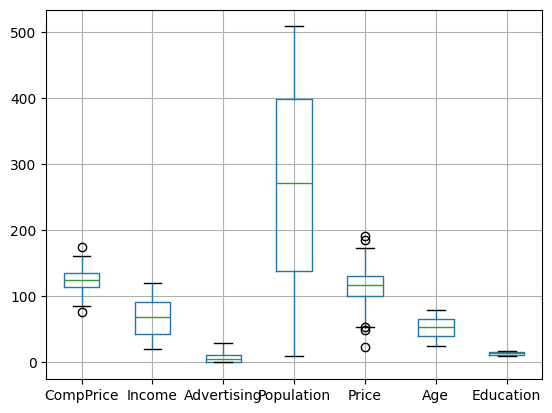

In [ ]:
df.boxplot()

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  IQR=q3-q1
  upper=q3+(1.5*IQR)
  lower=q1-(1.5*IQR)
  df[i]=df[i].clip(lower,upper)

<Axes: >

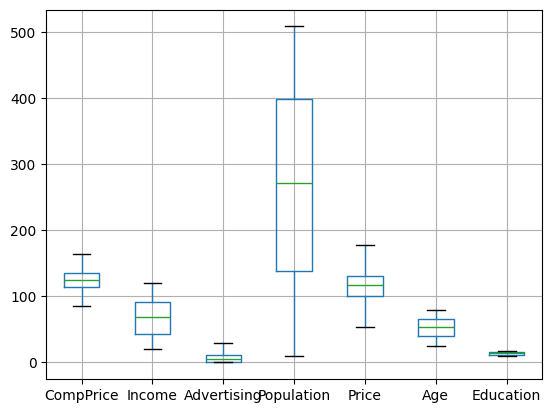

In [ ]:
df.boxplot()

In [ ]:
df

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,138,73,11,276,120.0,Bad,42,17,Yes,Yes,yes
1,111,48,16,260,83.0,Good,65,10,Yes,Yes,yes
2,113,35,10,269,80.0,Medium,59,12,Yes,Yes,yes
3,117,100,4,466,97.0,Medium,55,14,Yes,Yes,no
4,141,64,3,340,128.0,Bad,38,13,Yes,No,no
...,...,...,...,...,...,...,...,...,...,...,...
395,138,108,17,203,128.0,Good,33,14,Yes,Yes,yes
396,139,23,3,37,120.0,Medium,55,11,No,Yes,no
397,162,26,12,368,159.0,Medium,40,18,Yes,Yes,no
398,100,79,7,284,95.0,Bad,50,12,Yes,Yes,no


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df[['ShelveLoc']]=oe.fit_transform(df[['ShelveLoc']])
df

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,138,73,11,276,120.0,0.0,42,17,Yes,Yes,yes
1,111,48,16,260,83.0,1.0,65,10,Yes,Yes,yes
2,113,35,10,269,80.0,2.0,59,12,Yes,Yes,yes
3,117,100,4,466,97.0,2.0,55,14,Yes,Yes,no
4,141,64,3,340,128.0,0.0,38,13,Yes,No,no
...,...,...,...,...,...,...,...,...,...,...,...
395,138,108,17,203,128.0,1.0,33,14,Yes,Yes,yes
396,139,23,3,37,120.0,2.0,55,11,No,Yes,no
397,162,26,12,368,159.0,2.0,40,18,Yes,Yes,no
398,100,79,7,284,95.0,0.0,50,12,Yes,Yes,no


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['high']=le.fit_transform(df['high'])
df

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,138,73,11,276,120.0,0.0,42,17,Yes,Yes,1
1,111,48,16,260,83.0,1.0,65,10,Yes,Yes,1
2,113,35,10,269,80.0,2.0,59,12,Yes,Yes,1
3,117,100,4,466,97.0,2.0,55,14,Yes,Yes,0
4,141,64,3,340,128.0,0.0,38,13,Yes,No,0
...,...,...,...,...,...,...,...,...,...,...,...
395,138,108,17,203,128.0,1.0,33,14,Yes,Yes,1
396,139,23,3,37,120.0,2.0,55,11,No,Yes,0
397,162,26,12,368,159.0,2.0,40,18,Yes,Yes,0
398,100,79,7,284,95.0,0.0,50,12,Yes,Yes,0


In [ ]:
df=pd.get_dummies(df,dtype='int')
df

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,high,Urban_No,Urban_Yes,US_No,US_Yes
0,138,73,11,276,120.0,0.0,42,17,1,0,1,0,1
1,111,48,16,260,83.0,1.0,65,10,1,0,1,0,1
2,113,35,10,269,80.0,2.0,59,12,1,0,1,0,1
3,117,100,4,466,97.0,2.0,55,14,0,0,1,0,1
4,141,64,3,340,128.0,0.0,38,13,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,138,108,17,203,128.0,1.0,33,14,1,0,1,0,1
396,139,23,3,37,120.0,2.0,55,11,0,1,0,0,1
397,162,26,12,368,159.0,2.0,40,18,0,0,1,0,1
398,100,79,7,284,95.0,0.0,50,12,0,0,1,0,1


In [ ]:
x=df.drop(columns='high')
y=df['high']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=50,stratify=df.high)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier()
DT.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
pred_train=DT.predict(x_train)
pred_test=DT.predict(x_test)
from sklearn.metrics import accuracy_score
print("Train Score is:",accuracy_score(y_train,pred_train))
print("Test Score is:",accuracy_score(y_test,pred_test))

Train Score is: 1.0
Test Score is: 0.7666666666666667


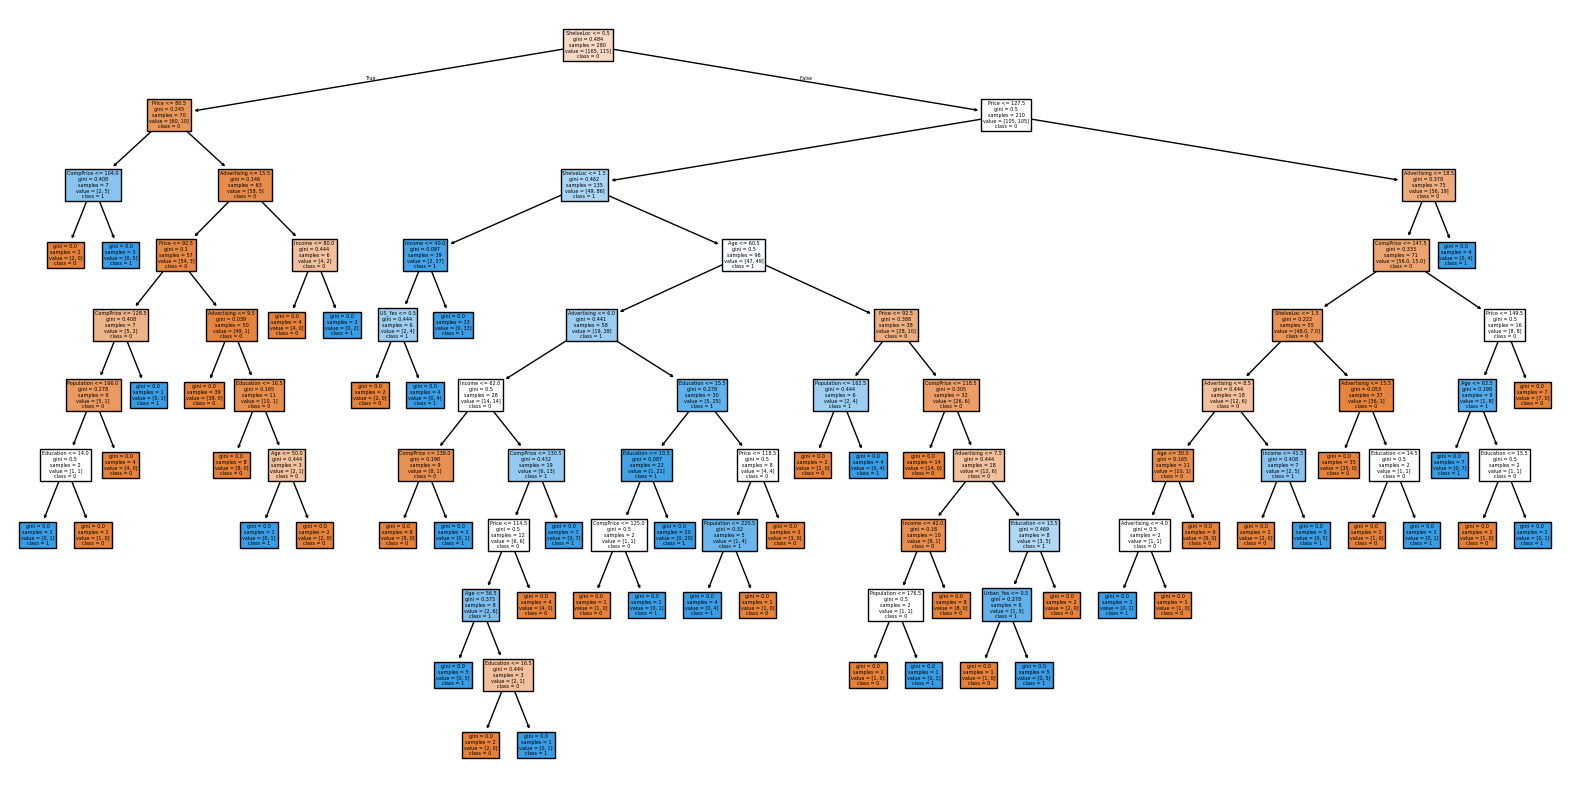

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    DT,  # model name
    filled=True,
    feature_names=x.columns,
    class_names=['0', '1'],
)
plt.show()

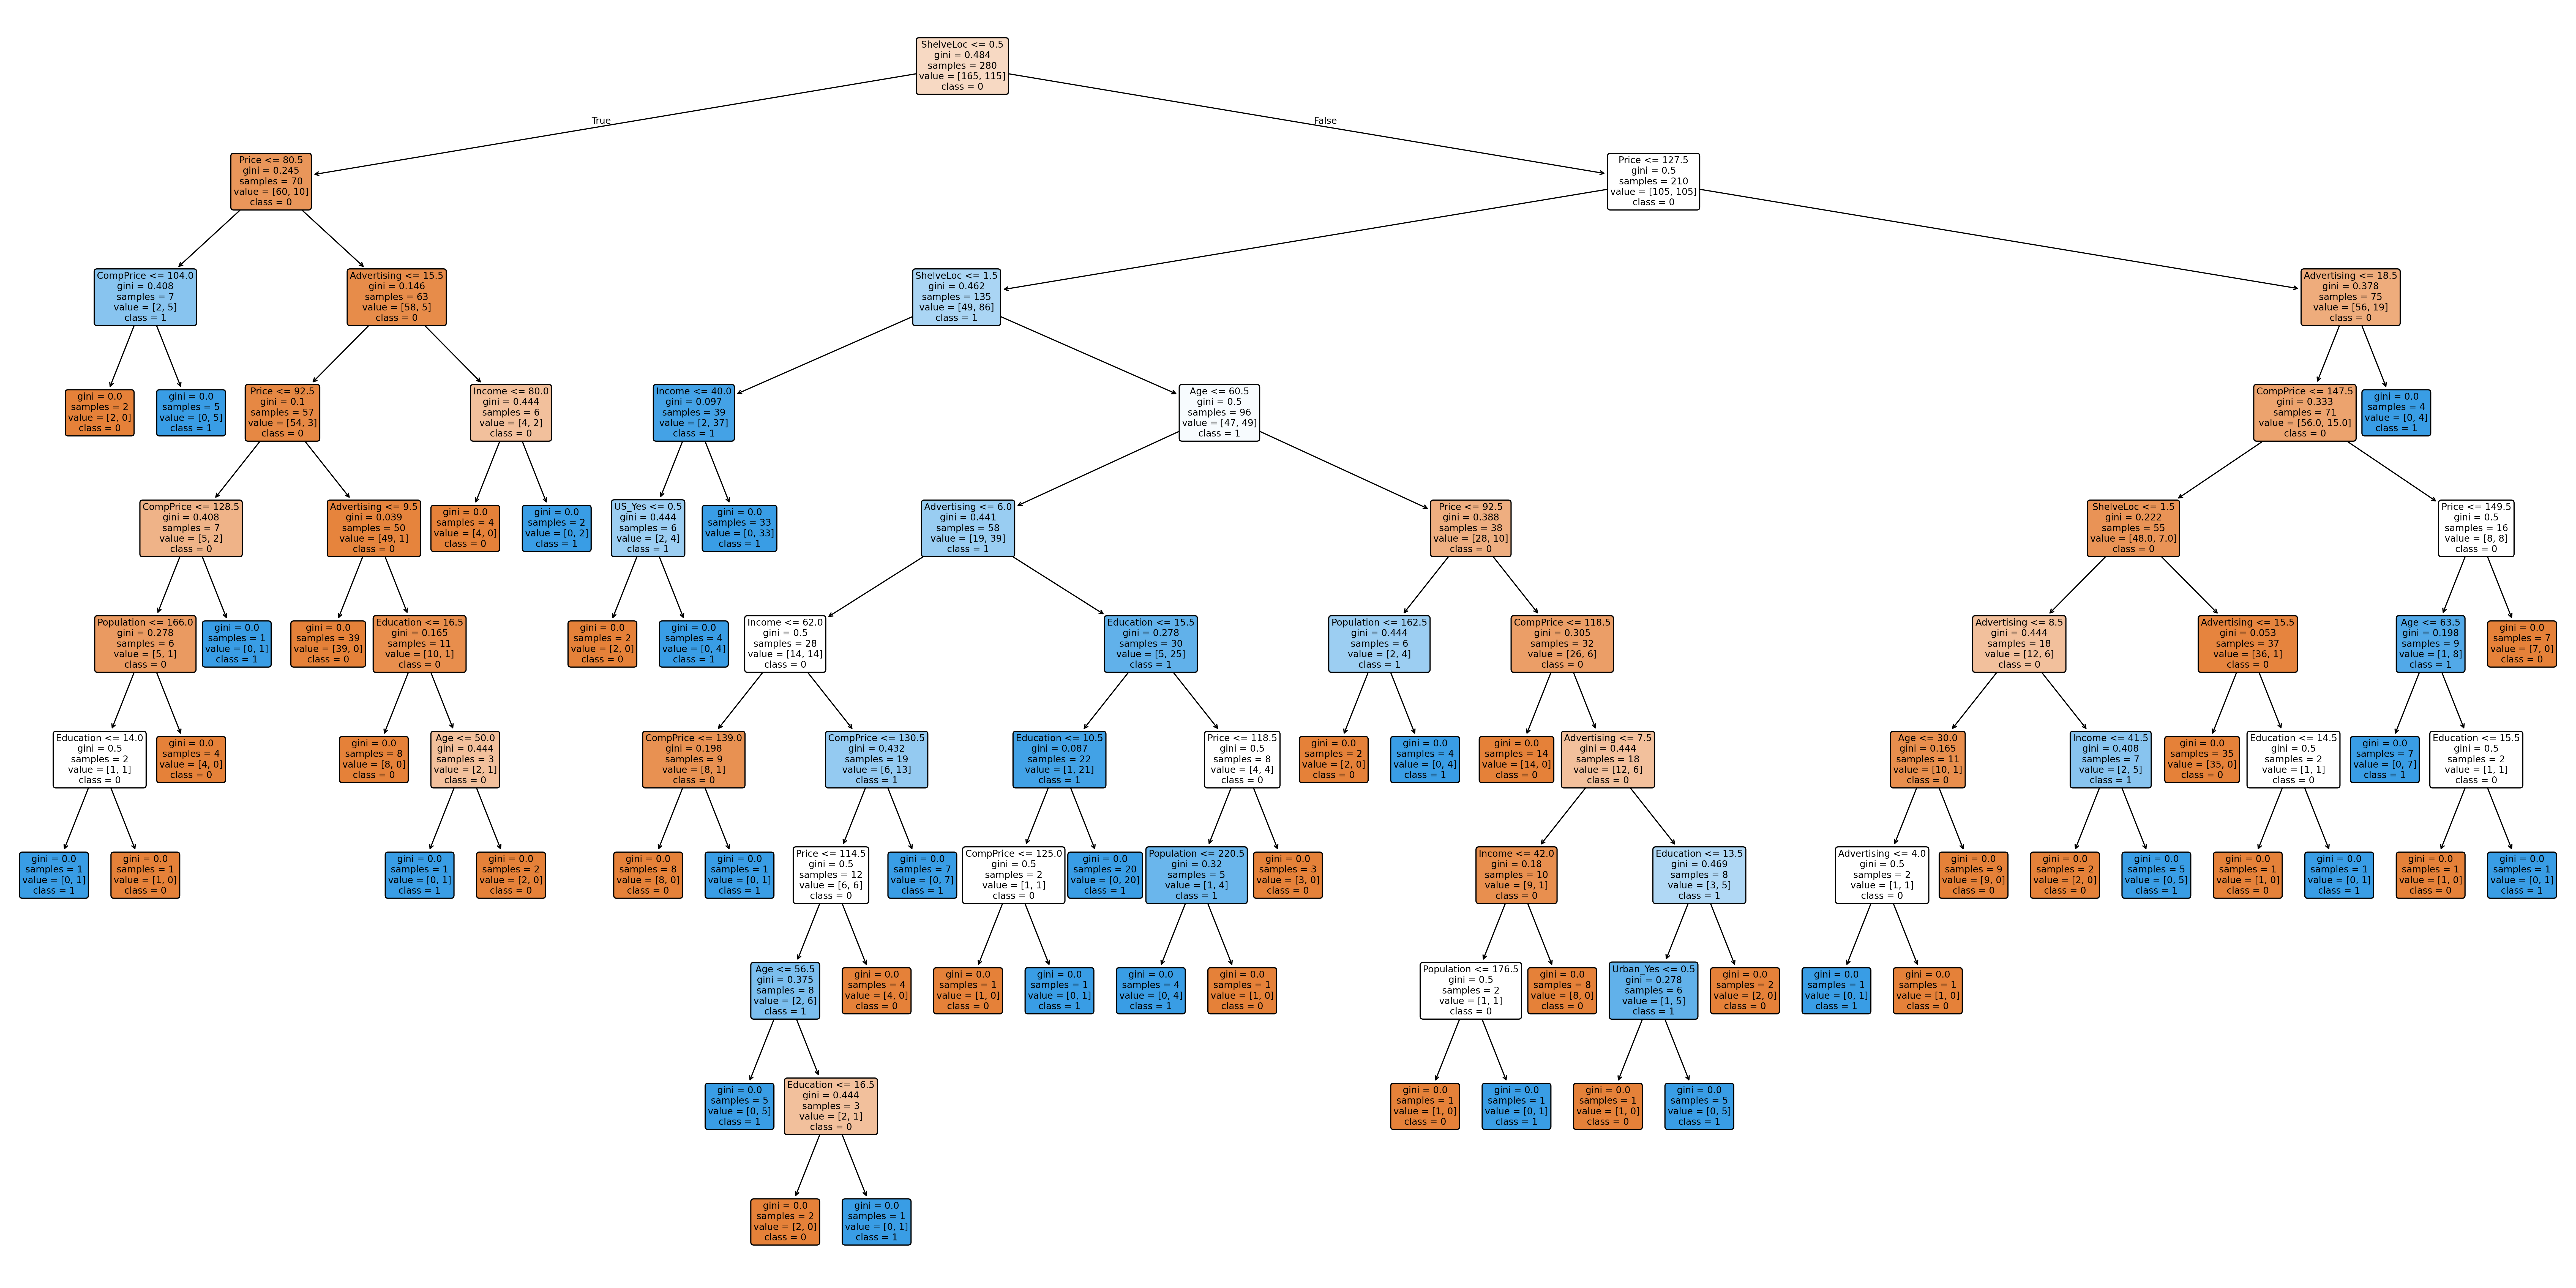

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(40, 20), dpi=300)

plot_tree(
    DT,
    filled=True,
    rounded=True,
    fontsize=8,
    feature_names=x.columns,
    class_names=['0', '1']
)

plt.savefig("decision_tree.pdf", bbox_inches="tight")
plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier(criterion="entropy",splitter='random',max_depth=4)
DT.fit(x_train,y_train)
pred_train=DT.predict(x_train)
pred_test=DT.predict(x_test)
from sklearn.metrics import accuracy_score
print("Train Score is:",accuracy_score(y_train,pred_train))
print("Test Score is:",accuracy_score(y_test,pred_test))

Train Score is: 0.7857142857142857
Test Score is: 0.7583333333333333


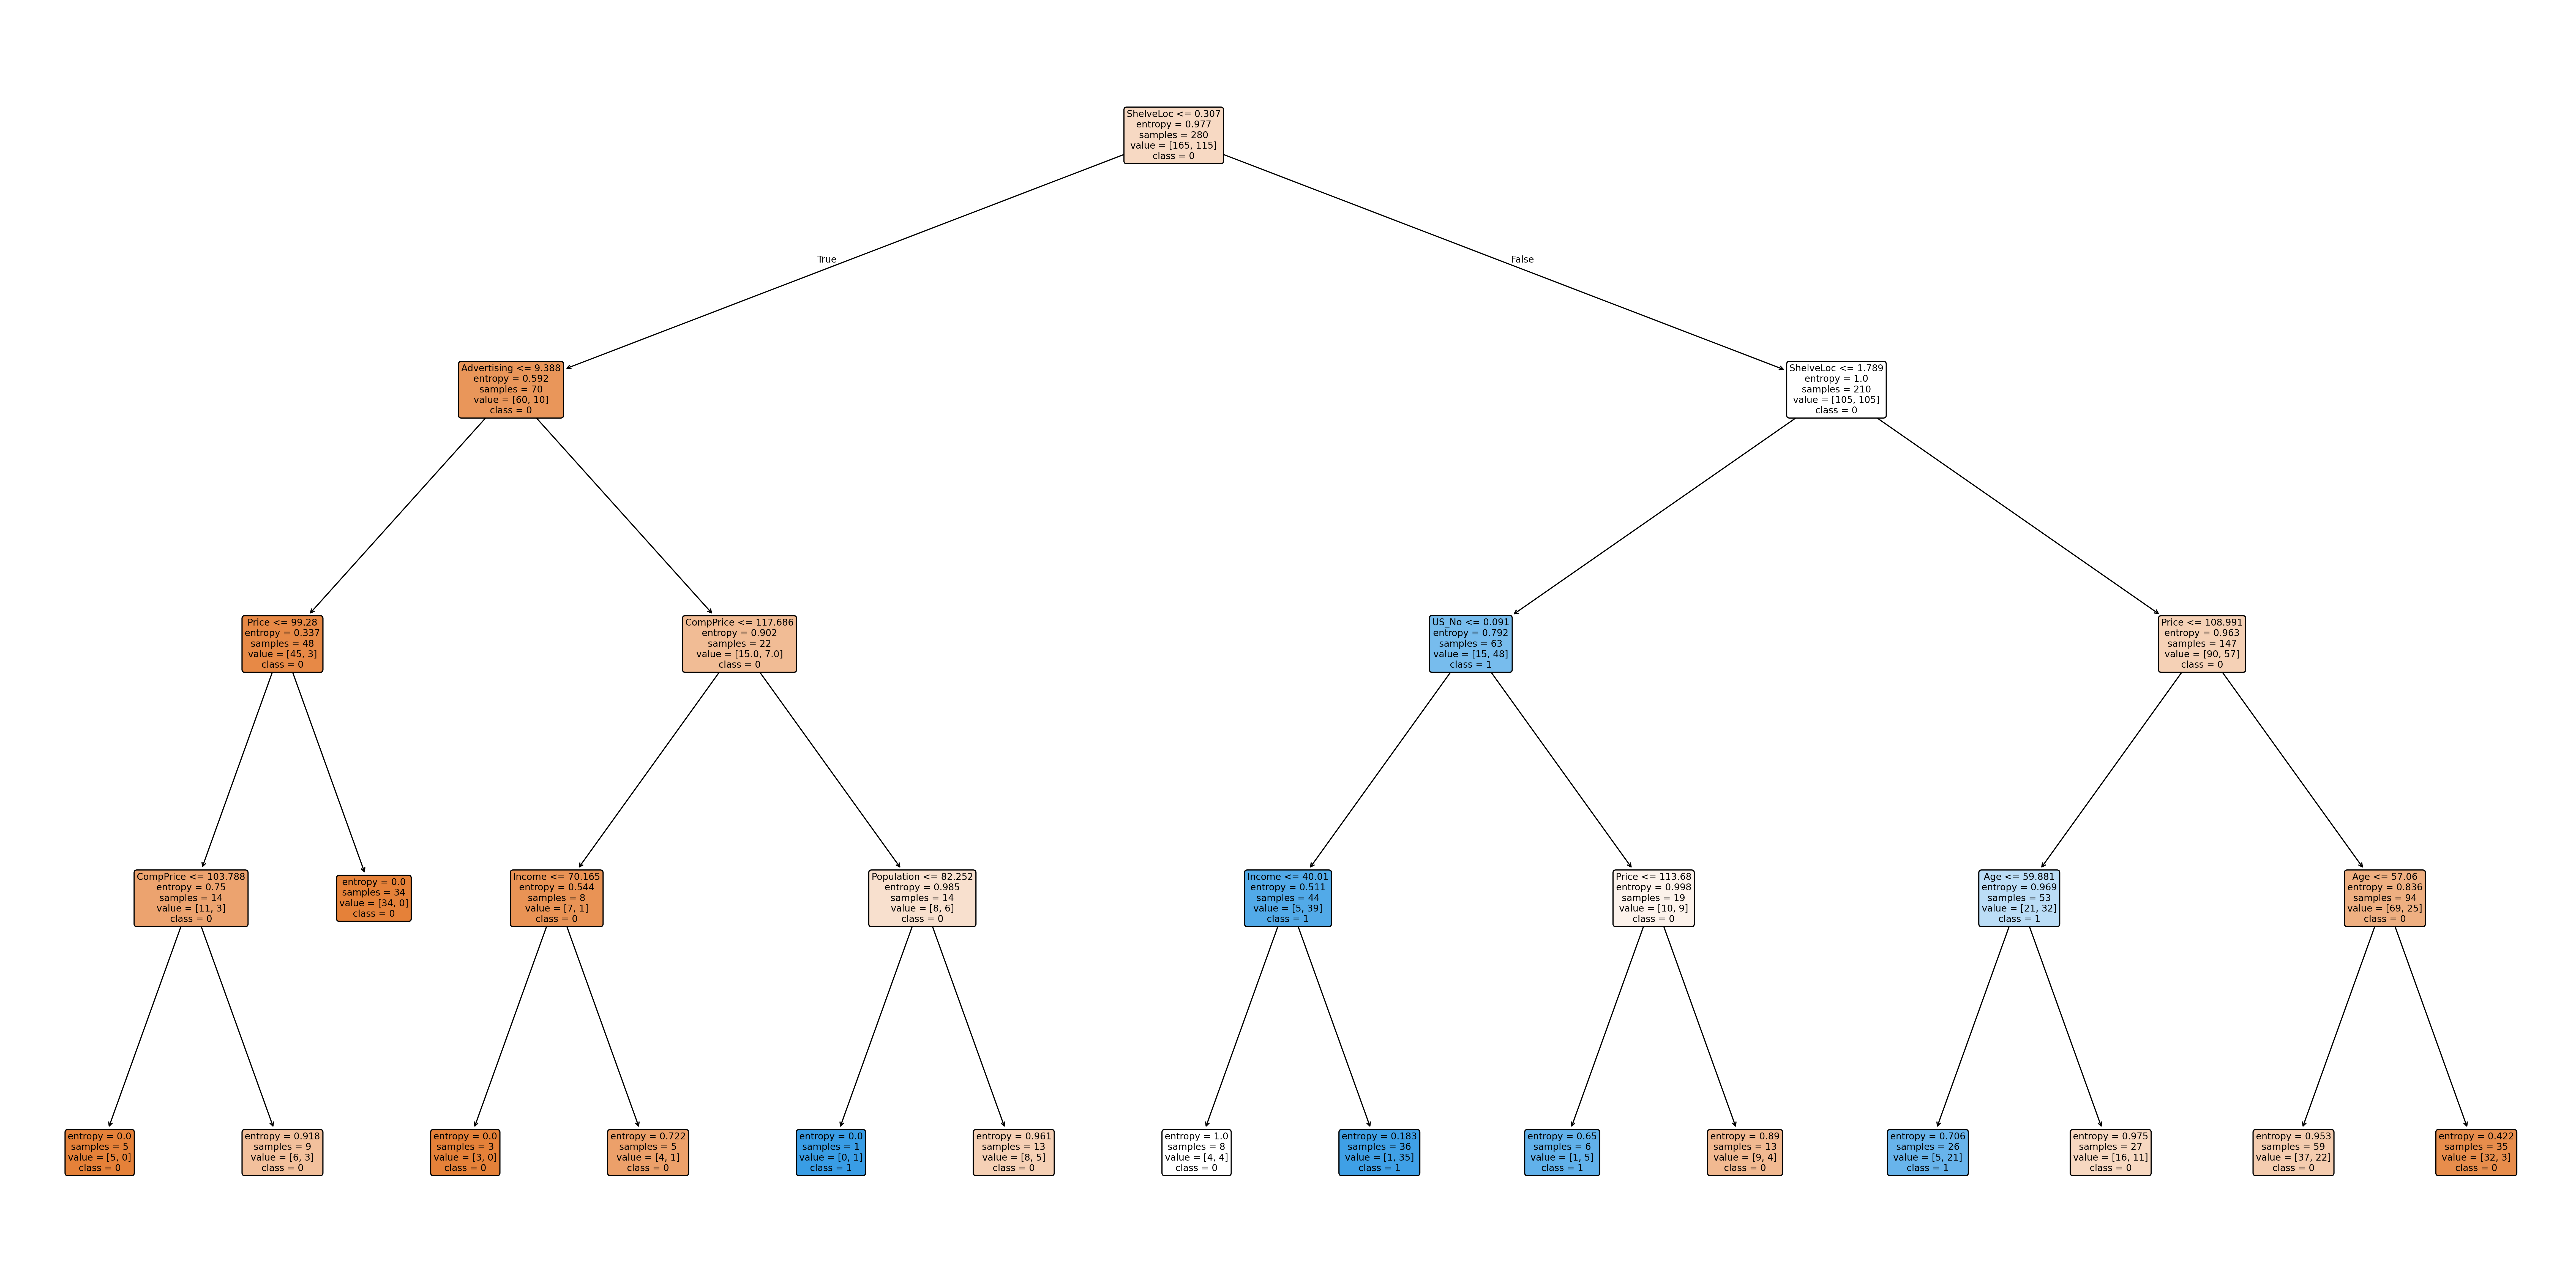

In [ ]:
plt.figure(figsize=(40, 20), dpi=300)

plot_tree(
    DT,
    filled=True,
    rounded=True,
    fontsize=8,
    feature_names=x.columns,
    class_names=['0', '1']
)

plt.savefig("decision_tree.pdf", bbox_inches="tight")
#plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier()
DT.fit(x_train,y_train)
pred_train=DT.predict(x_train)
pred_test=DT.predict(x_test)
from sklearn.metrics import accuracy_score
print("Train Score is:",accuracy_score(y_train,pred_train))
print("Test Score is:",accuracy_score(y_test,pred_test))

Train Score is: 1.0
Test Score is: 0.775


In [ ]:
from sklearn.model_selection import GridSearchCV
params={'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':range(1,7)}
grid_search=GridSearchCV(estimator=DT,param_grid=params,cv=5)
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 7),
                         'splitter': ['best', 'random']})

In [ ]:
from sklearn.model_selection import GridSearchCV
params={'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':range(1,7)}
grid_search=GridSearchCV(estimator=DT,param_grid=params,cv=5)
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 7),
                         'splitter': ['best', 'random']})

In [ ]:
grid_search.best_score_,grid_search.best_params_

(np.float64(0.7392857142857143),
 {'criterion': 'gini', 'max_depth': 6, 'splitter': 'best'})

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier(criterion='entropy',max_depth=4,splitter='random')
DT.fit(x_train,y_train)
pred_train=DT.predict(x_train)
pred_test=DT.predict(x_test)
from sklearn.metrics import accuracy_score
print("Train Score is:",accuracy_score(y_train,pred_train))
print("Test Score is:",accuracy_score(y_test,pred_test))

Train Score is: 0.775
Test Score is: 0.7666666666666667
